In [1]:
import geopandas as gpd 
import pandas as pd
import matplotlib.pyplot as plt


%matplotlib inline
%config InlineBackend.figure_format = 'retina'


In [2]:
gf = gpd.read_file('../data/GIS/SkagitSubBasin_HUC8.geojson')
gf_b = gf[gf.Name.isin(['Upper Skagit', 'Lower Skagit', 'Sauk'])]
gf_b

,OBJECTID,AreaAcres,AreaSqKm,States,HUC8,Name,TNMID,LoadDate,GNIS_ID,GlobalID,geometry
29,30,1286652.51,5206.90,"CN,WA",17110005,Upper Skagit,{BEF5D139-B56E-43A5-A9A7-EB27E6F0B6A9},"Fri, 18 Jan 2013 13:55:14 GMT",None,4475071d-73f2-4677-8bc6-9be98fc3ac6a,"POLYGON ((-120.99842 49.31152, -120.99836 49.3..."
65,66,468724.20,1896.86,WA,17110006,Sauk,{DB785059-BDAB-402A-B6B6-2575A82A8381},"Fri, 18 Jan 2013 13:55:14 GMT",None,d2b15bce-ed33-4152-b761-60a7add8fab7,"POLYGON ((-121.60702 48.48140, -121.60401 48.4..."
66,67,289711.45,1172.42,WA,17110007,Lower Skagit,{BB64475B-E0E8-4D0F-8DC4-3C9DA047A02B},"Fri, 18 Jan 2013 13:55:14 GMT",None,05bfeac3-1f44-4fe7-8725-20f9ece30909,"MULTIPOLYGON (((-121.81821 48.61408, -121.8173..."


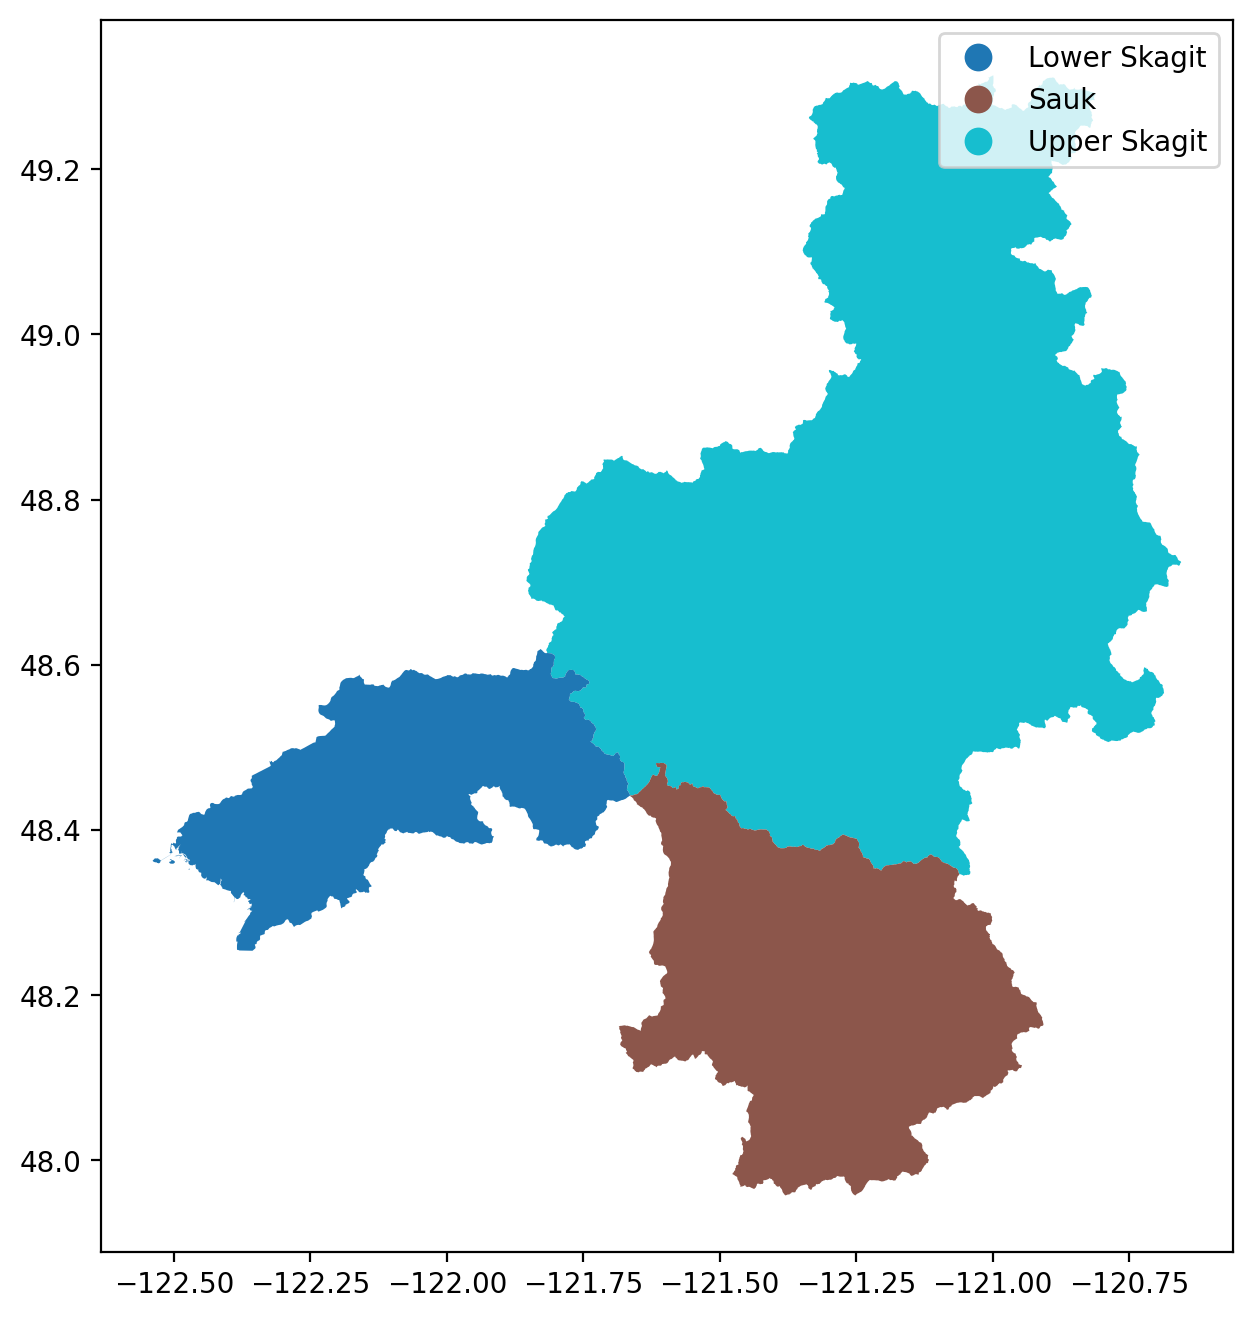

In [3]:
gf_b.plot(column='Name', categorical=True, legend=True, figsize=(8,8));
#gf_b.plot(color='Name', legend=True)

In [4]:
all_stations_gdf = gpd.read_file('https://raw.githubusercontent.com/egagli/snotel_ccss_stations/main/all_stations.geojson').set_index('code')
all_stations_gdf = all_stations_gdf[all_stations_gdf['csvData']==True]

In [5]:
aoi = gpd.read_file('../data/GIS/SkagitBoundary.json')
gf = all_stations_gdf.clip(aoi)
gf

,name,network,elevation_m,latitude,longitude,state,HUC,mgrs,mountainRange,beginDate,endDate,csvData,geometry
code,,,,,,,,,,,,,
711_WA_SNTL,Rainy Pass,SNOTEL,1490.472046,48.518650,-120.735802,Washington,171100050503,10UFU,Cascade Range,1979-10-01 00:00:00,2025-12-02,True,POINT (-120.73580 48.51865)
817_WA_SNTL,Thunder Basin,SNOTEL,1316.735962,48.527531,-120.989502,Washington,171100050702,10UFU,Cascade Range,1987-09-30 00:00:00,2025-12-02,True,POINT (-120.98950 48.52753)
975_WA_SNTL,Swamp Creek,SNOTEL,1197.864014,48.571419,-120.782669,Washington,171100050503,10UFU,Cascade Range,1999-10-01 00:00:00,2025-12-02,True,POINT (-120.78267 48.57142)
999_WA_SNTL,Marten Ridge,SNOTEL,1072.895996,48.762920,-121.698227,Washington,171100051004,10UEV,Cascade Range,2006-07-01 00:00:00,2025-12-02,True,POINT (-121.69823 48.76292)
998_WA_SNTL,Easy Pass,SNOTEL,1606.296021,48.859329,-121.438950,Washington,171100010101,10UFV,Cascade Range,2008-09-19 00:00:00,2025-12-02,True,POINT (-121.43895 48.85933)
990_WA_SNTL,Beaver Pass,SNOTEL,1106.423950,48.879299,-121.255501,Washington,171100050605,10UFV,Cascade Range,2000-10-01 00:00:00,2025-12-02,True,POINT (-121.25550 48.87930)
1080_WA_SNTL,Brown Top,SNOTEL,1776.984009,48.927551,-121.197128,Washington,171100050601,10UFV,Cascade Range,2009-09-15 11:00:00,2025-09-28,True,POINT (-121.19713 48.92755)


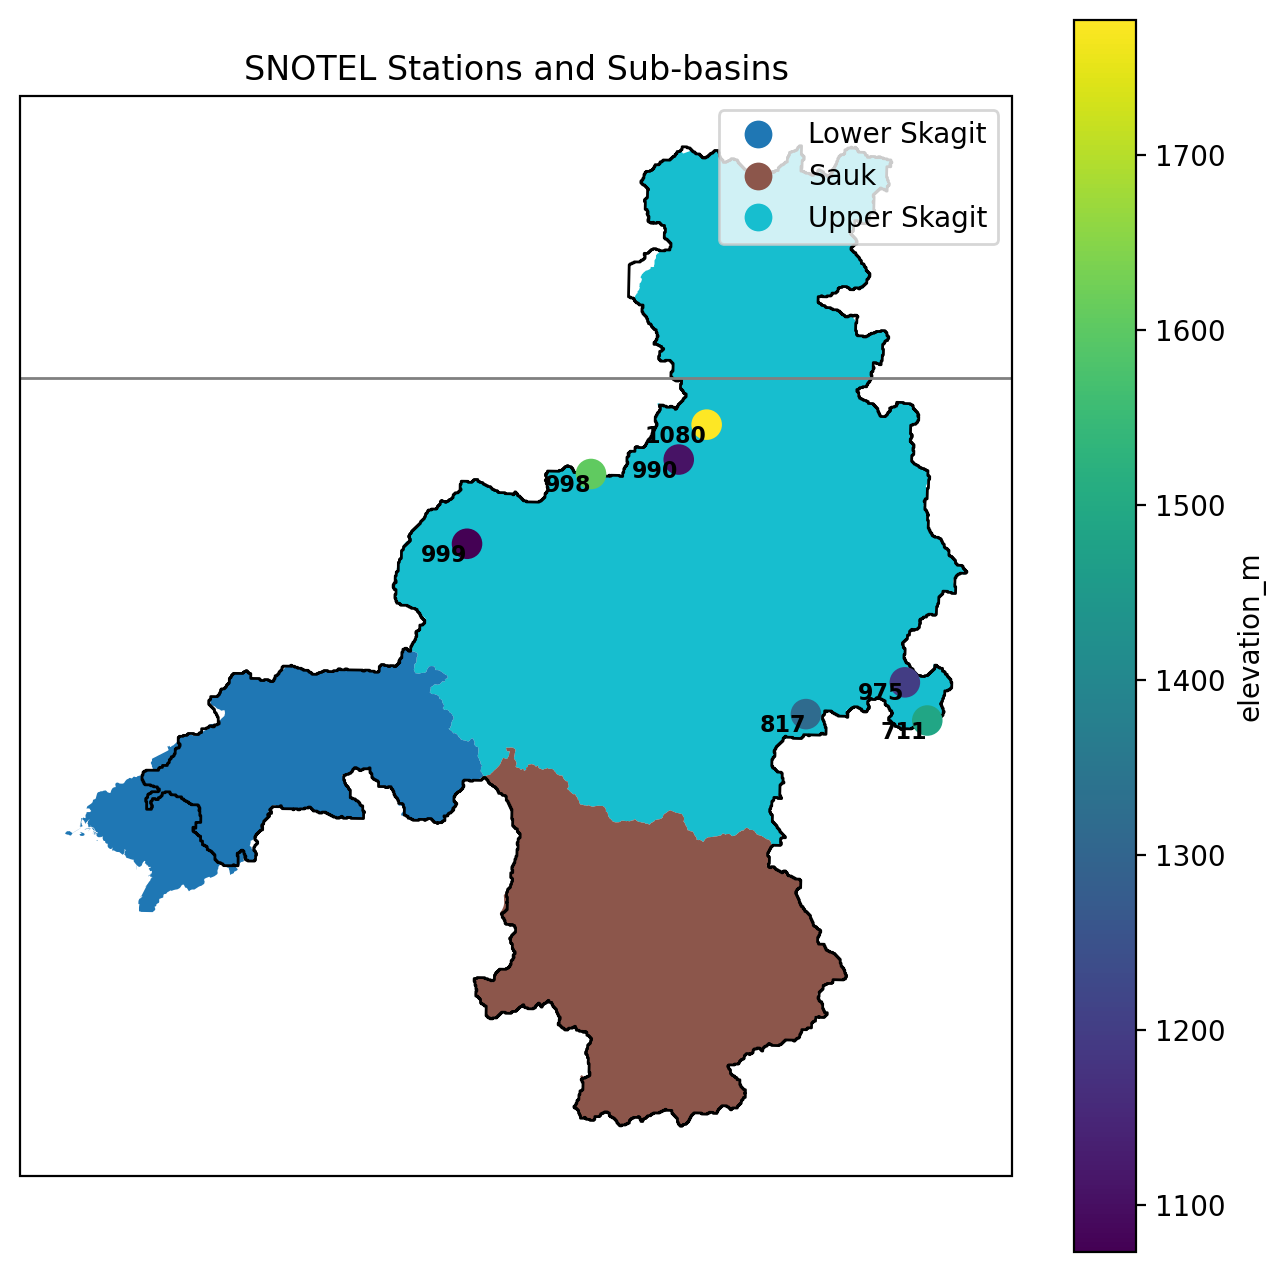

In [ ]:

import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig, ax = plt.subplots(figsize=(8,8), subplot_kw={'projection': ccrs.PlateCarree()})

ax.set_title('SNOTEL Stations and Sub-basins')

# Add Canadian border
ax.add_feature(cfeature.BORDERS, edgecolor='gray', linewidth=1)


for idx, row in gf.iterrows():
    plt.text(row['longitude'], row['latitude'], idx.rstrip('_WA_SNTL'), fontsize=8, fontweight='bold', ha='right', va='top')
    
gf_b.plot(ax=ax, column='Name', categorical=True, legend=True)#, legend_kwds={'loc': 'upper left'})

aoi.plot(ax=ax, edgecolor='black', facecolor='none')
gf.plot.scatter(x='longitude', y='latitude', c='elevation_m', ax=ax, s=100);
#plt.legend(loc='upper left')

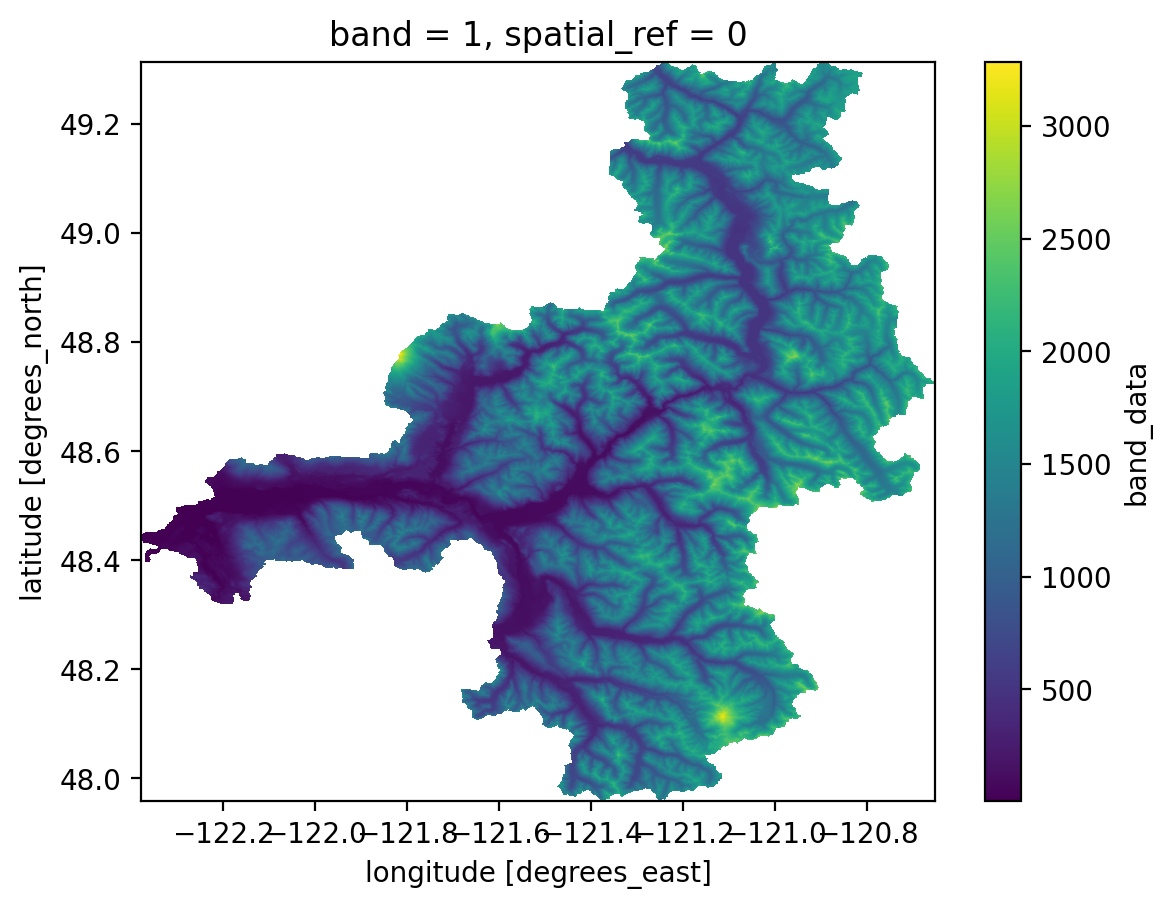

In [18]:
# Look at elevation distributions per sub-basin 
import xarray as xr 
dem = xr.open_dataarray('../data/GIS/SkagitRiver_90mDEM.tif').rio.clip(
                            aoi.geometry).squeeze()
dem.plot.imshow(robust=False)

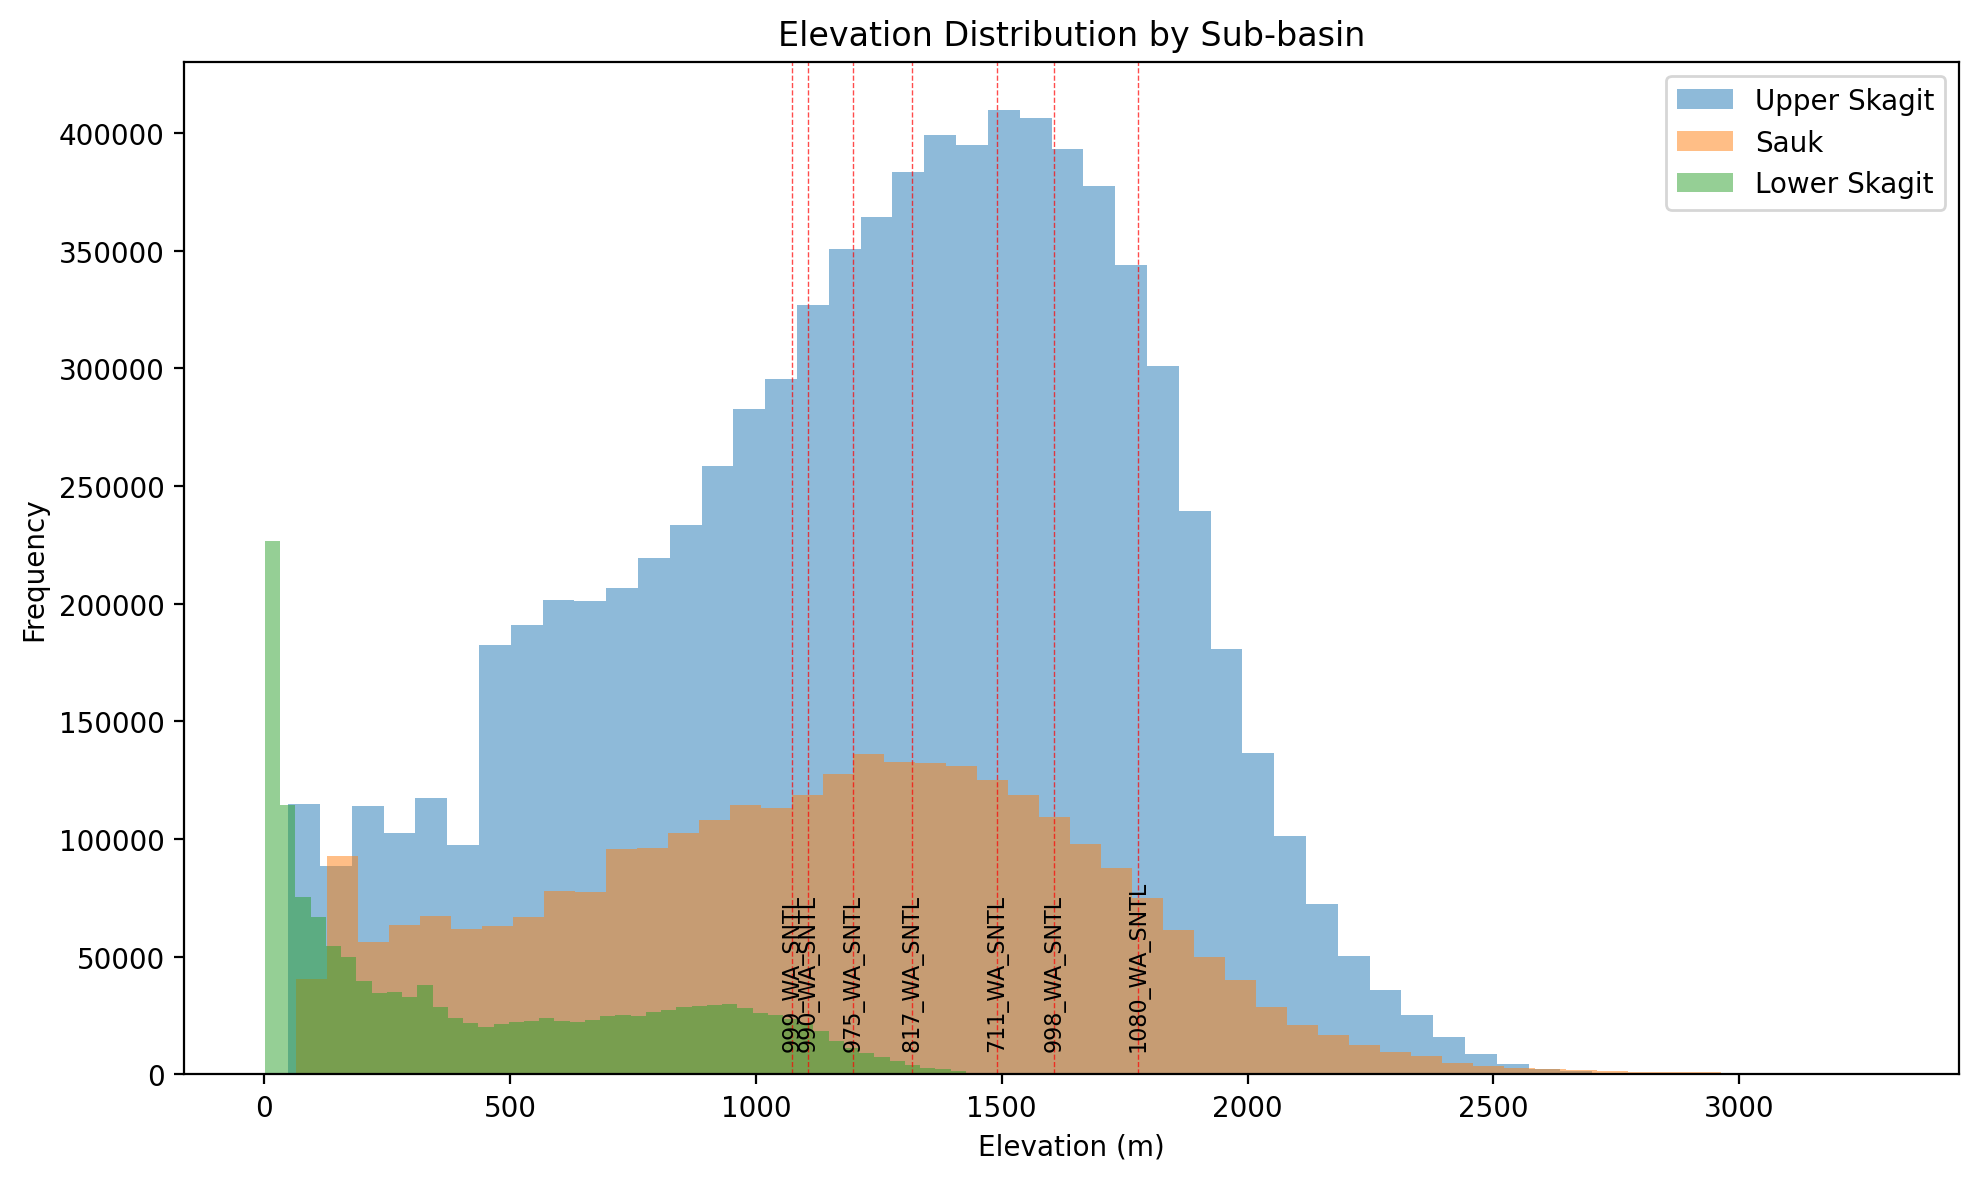

In [29]:
#dem.rio.clip(gf_b[gf_b.Name == 'Sauk'].geometry)
fig, ax = plt.subplots(figsize=(10, 6))

# Add rotated text labels for each station at their elevation
for station_idx, station_row in gf.iterrows():
    ax.text(station_row['elevation_m'], 10000, station_idx,  # .rstrip('_WA_SNTL')
            rotation=90, verticalalignment='bottom', horizontalalignment='center', fontsize=8)
    ax.axvline(station_row['elevation_m'], color='red', linestyle='--', linewidth=0.5, alpha=0.7)

for idx, row in gf_b.iterrows():
    clipped_dem = dem.rio.clip([row.geometry])
    clipped_dem.plot.hist(ax=ax, alpha=0.5, label=row['Name'], bins=50)

ax.set_xlabel('Elevation (m)')
ax.set_ylabel('Frequency')
ax.set_title('Elevation Distribution by Sub-basin')
ax.legend()
plt.tight_layout()


In [47]:
station_list = gf.index.tolist()
station_list

['711_WA_SNTL',
 '817_WA_SNTL',
 '975_WA_SNTL',
 '999_WA_SNTL',
 '998_WA_SNTL',
 '990_WA_SNTL',
 '1080_WA_SNTL']

In [31]:
# Get time series for each station for a particular year 
#station_id = '679_WA_SNTL'
#paradise_snotel = pd.read_csv(f'https://raw.githubusercontent.com/egagli/snotel_ccss_stations/main/data/{station_id}.csv',index_col='datetime', parse_dates=True)

station_dfs = {
    station_id: pd.read_csv(
        f'https://raw.githubusercontent.com/egagli/snotel_ccss_stations/main/data/{station_id}.csv',
        index_col='datetime',
        parse_dates=True
    )
    for station_id in station_list
}
#df = pd.read_csv(f'https://raw.githubusercontent.com/egagli/snotel_ccss_stations/main/data/{station_id}.csv',index_col='datetime', parse_dates=True)



In [49]:
# Get CSVs for 2016 for each station
#station = '711_WA_SNTL'
station =  '998_WA_SNTL'
df = station_dfs[station]
df.loc['2016'].info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 366 entries, 2016-01-01 to 2016-12-31
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   TAVG    365 non-null    float64
 1   TMIN    365 non-null    float64
 2   TMAX    365 non-null    float64
 3   SNWD    0 non-null      float64
 4   WTEQ    366 non-null    float64
 5   PRCPSA  337 non-null    float64
dtypes: float64(6)
memory usage: 20.0 KB


In [ ]:
df.tail()

,TAVG,TMIN,TMAX,SNWD,WTEQ,PRCPSA
datetime,,,,,,
2025-11-28,-0.9,-3.4,3.3,0.7874,0.3988,NaN
2025-11-29,0.0,-5.3,2.9,0.7874,0.4013,NaN
2025-11-30,-2.2,-6.9,1.9,0.7620,0.3962,NaN
2025-12-01,-1.7,-3.2,0.5,0.7620,0.4013,NaN
2025-12-02,NaN,NaN,NaN,0.7620,0.4166,NaN


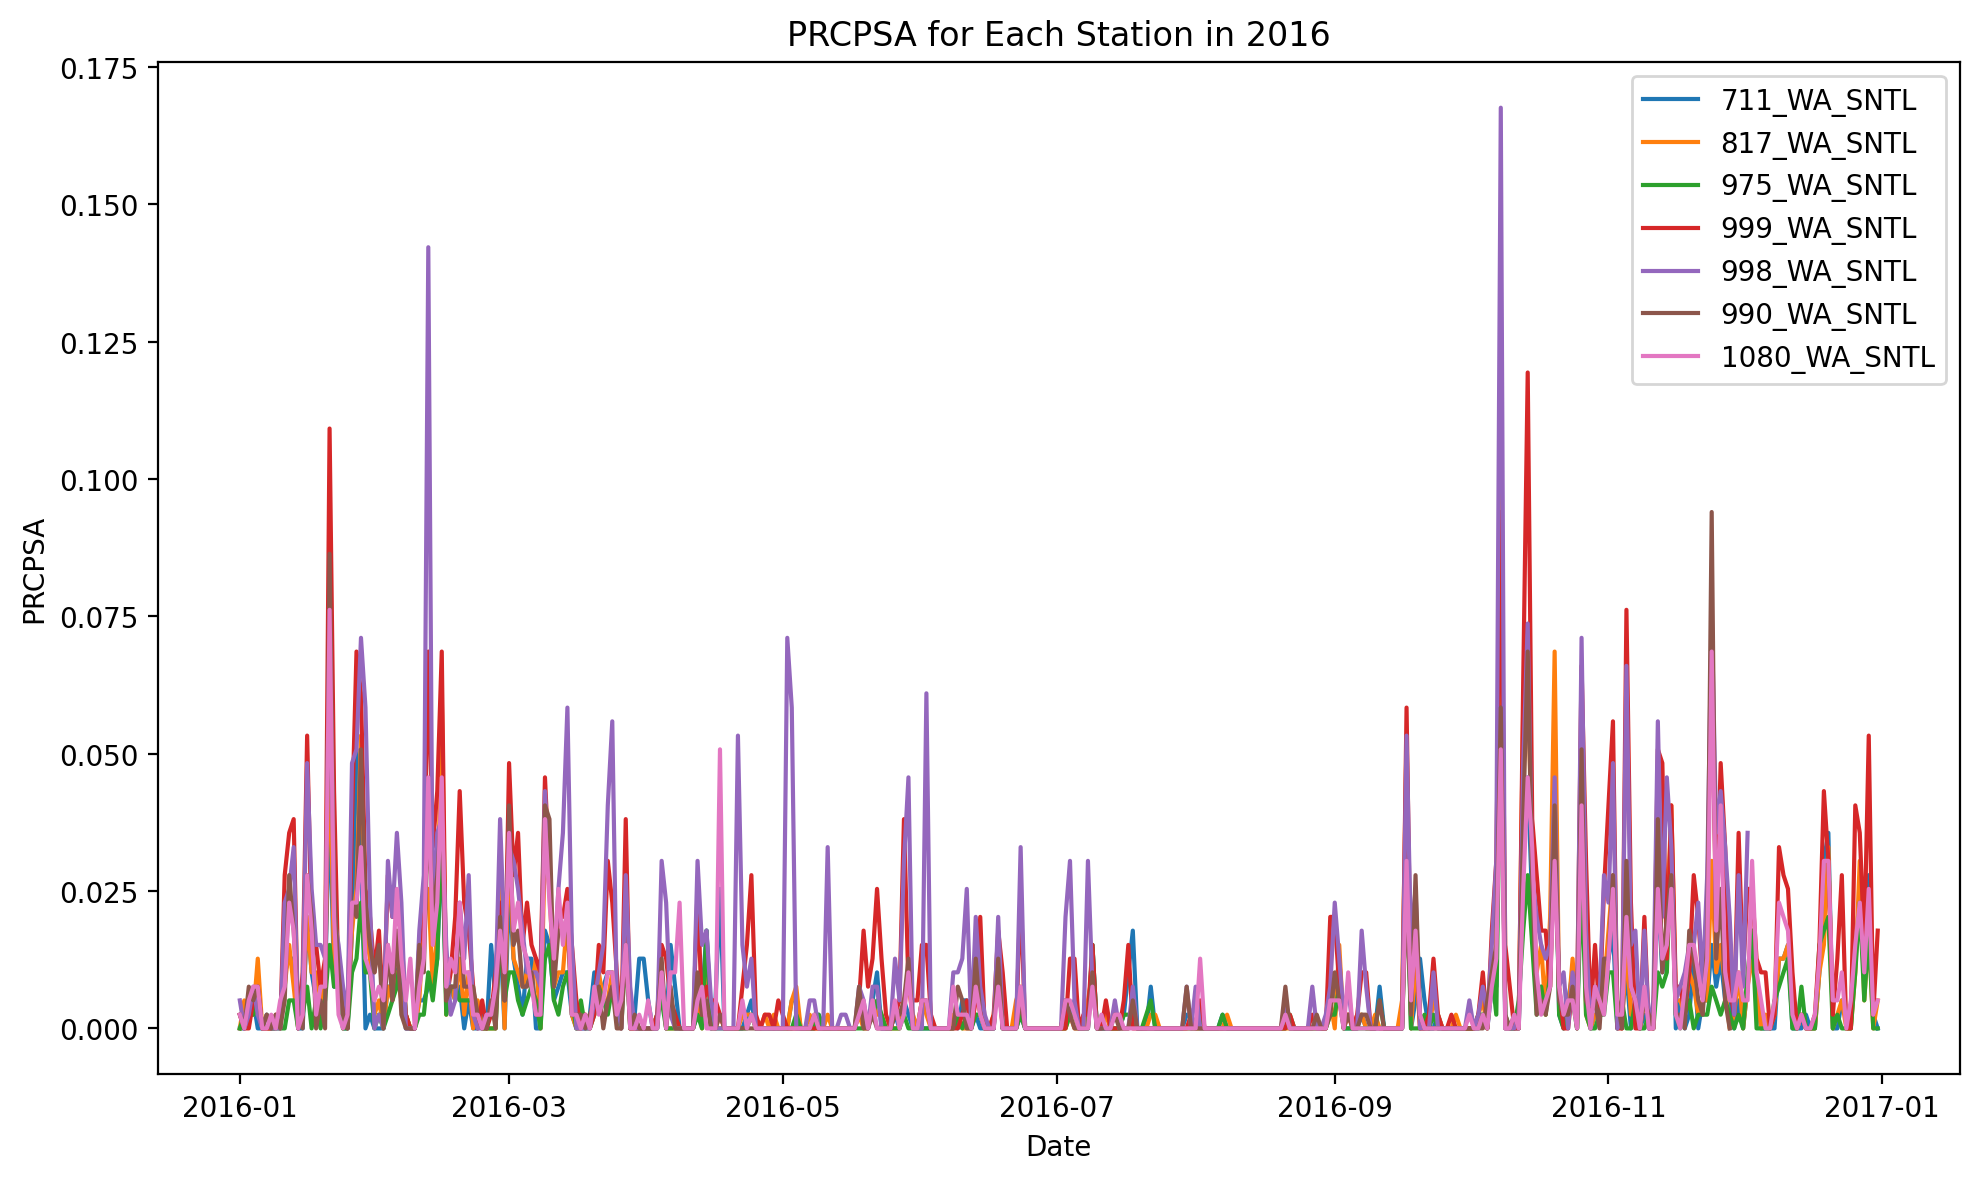

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
for station_id in station_list:
    df_station = station_dfs[station_id]
    df_2016 = df_station.loc['2016']
    plt.plot(df_2016.index, df_2016['PRCPSA'], label=station_id)

plt.xlabel('Date')
plt.ylabel('PRCPSA')
plt.title('PRCPSA for Each Station in 2016')
plt.legend()
plt.tight_layout()
plt.show()

In [52]:

# Count NaN values in PRCPSA for each station in 2016
nan_counts = {}
for station_id in station_list:
    df_station = station_dfs[station_id]
    df_2016 = df_station.loc['2016']
    nan_count = df_2016['PRCPSA'].isna().sum()
    nan_counts[station_id] = nan_count

print("NaN counts in PRCPSA for each station in 2016:")
for station_id, count in nan_counts.items():
    print(f"{station_id}: {count}")

NaN counts in PRCPSA for each station in 2016:
711_WA_SNTL: 0
817_WA_SNTL: 0
975_WA_SNTL: 0
999_WA_SNTL: 0
998_WA_SNTL: 29
990_WA_SNTL: 33
1080_WA_SNTL: 0


In [37]:
# Calculate average and standard deviation across all stations
all_cum_precip = []
for station_id in station_list:
    df_station = station_dfs[station_id]
    df_2016 = df_station.loc['2016']
    cum_precip_mm = df_2016['PRCPSA'].cumsum()
    all_cum_precip.append(cum_precip_mm)

# Align all series to the same index and calculate stats
cum_precip_df = pd.DataFrame(all_cum_precip).T
mean_cum_precip = cum_precip_df.mean(axis=1)
std_cum_precip = cum_precip_df.std(axis=1)

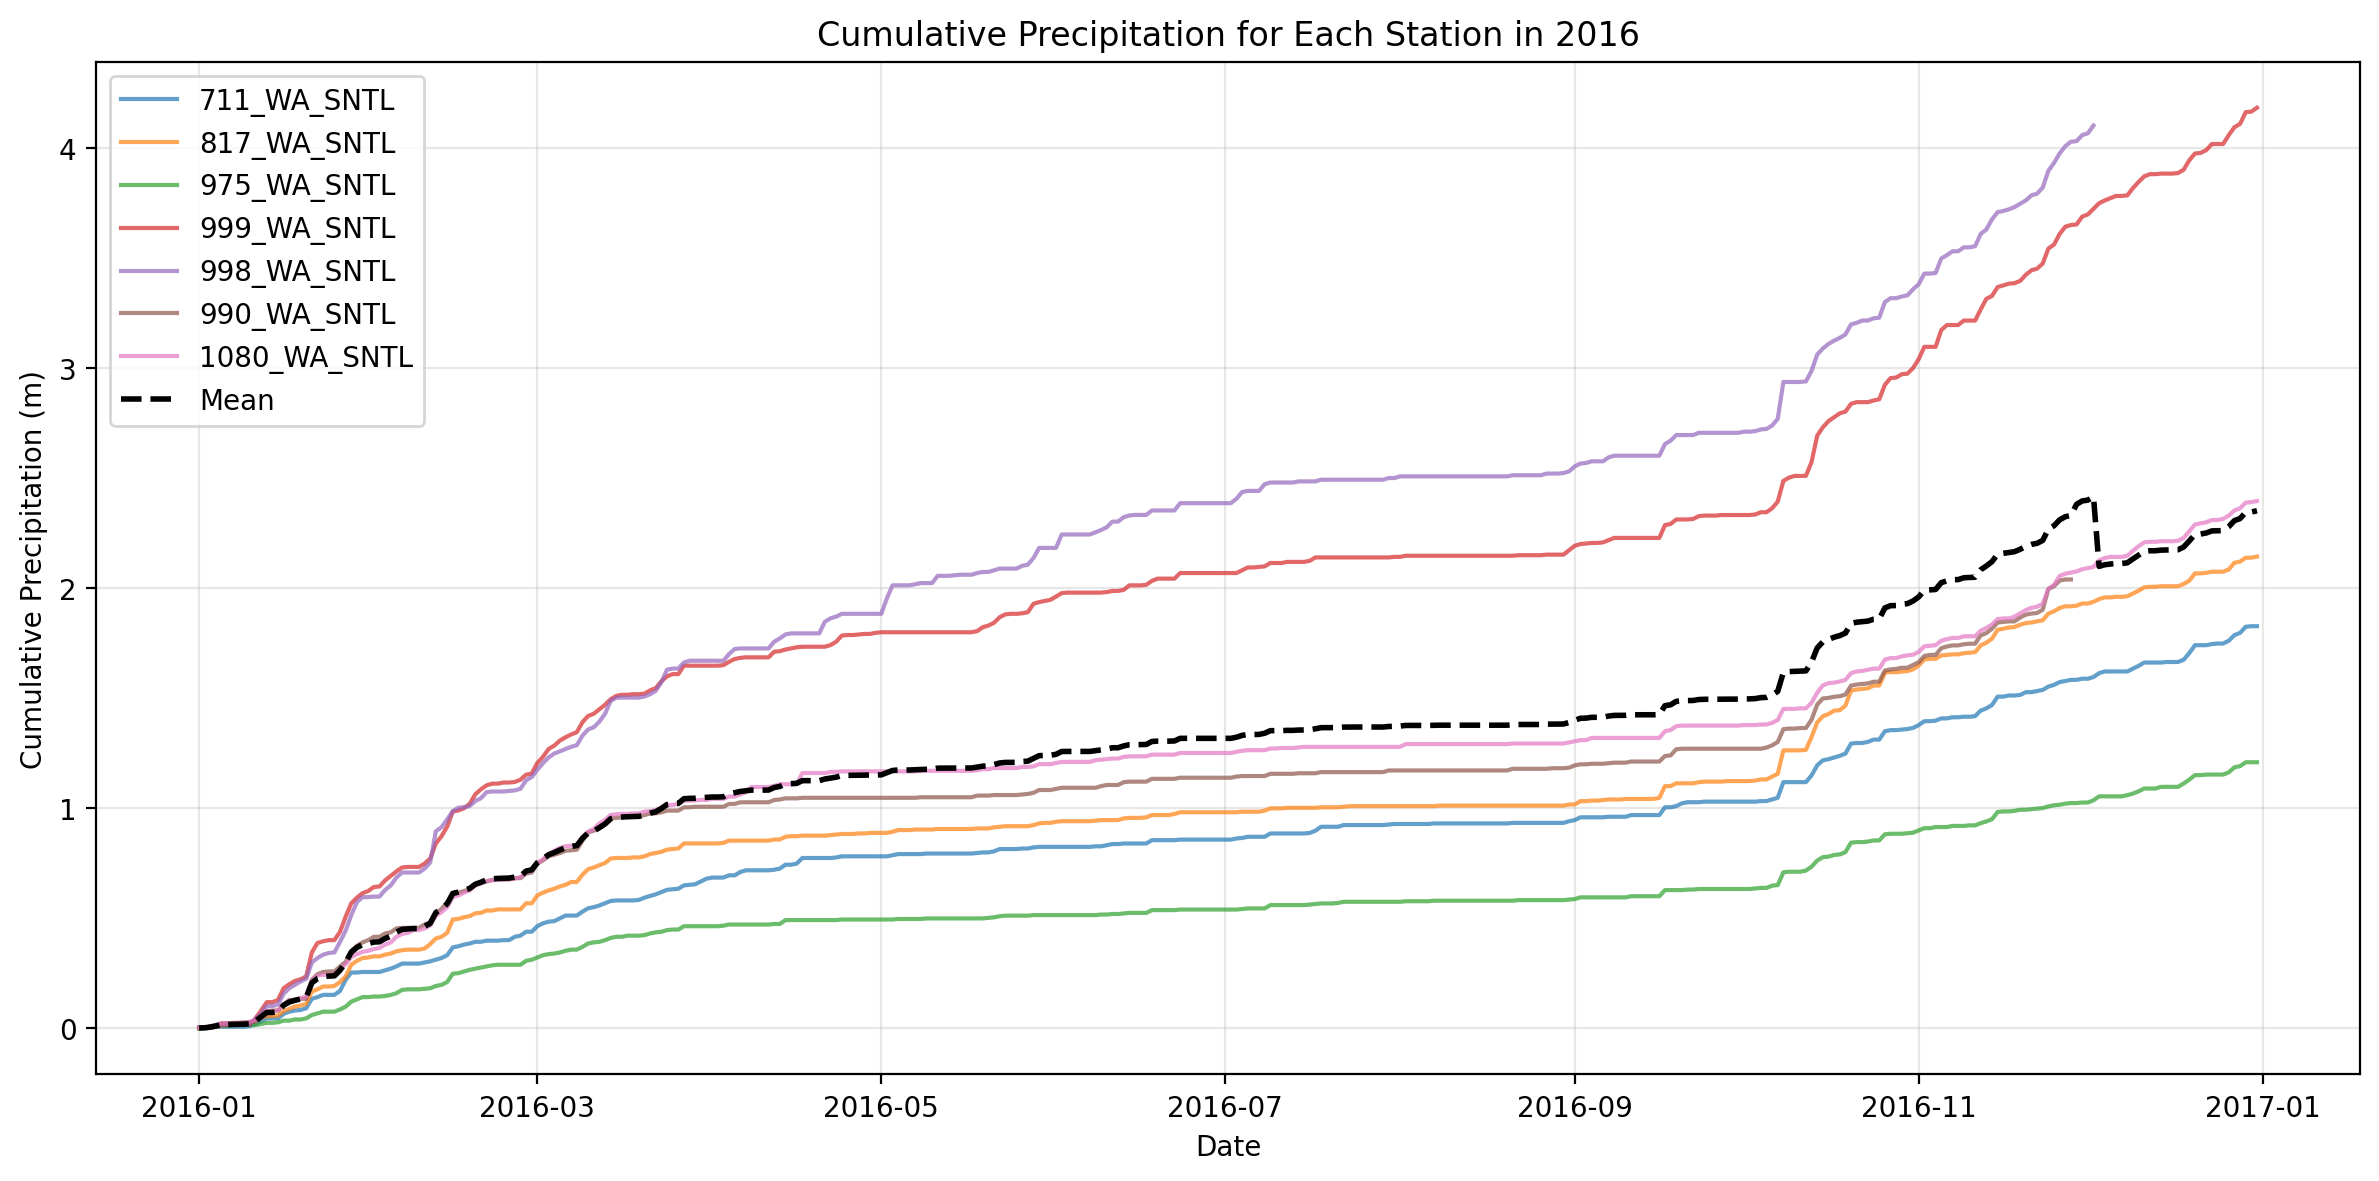

In [39]:
plt.figure(figsize=(12, 6))

# Plot each station's cumulative precipitation
for station_id in station_list:
    df_station = station_dfs[station_id]
    df_2016 = df_station.loc['2016']
    cum_precip = df_2016['PRCPSA'].cumsum()
    plt.plot(cum_precip.index, cum_precip, label=station_id, alpha=0.7)

# Plot the mean cumulative precipitation
plt.plot(mean_cum_precip.index, mean_cum_precip, label='Mean', color='black', linewidth=2, linestyle='--')

plt.xlabel('Date')
plt.ylabel('Cumulative Precipitation (m)')
plt.title('Cumulative Precipitation for Each Station in 2016')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()